# Advanced Portuguese STT with LLM Post-Processing
## Fixing Transcription Errors for European Portuguese Dental Clinic

This notebook addresses the issue where models fail to recognize basic Portuguese words like "dente".

**Strategy:**
1. Diagnose audio quality issues
2. Test models with enhanced preprocessing
3. Apply LLM-powered correction
4. Test forced vocabulary injection
5. Try phoneme-based approaches

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Setup

In [2]:
# Install packages
!pip install -q transformers torch torchaudio librosa soundfile accelerate
!pip install -q faster-whisper openai anthropic
!pip install -q noisereduce pydub
!pip install -q groq  # To compare with your current setup

print("✅ Packages installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 11.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 62.8 kB/s eta 0:00:00a 0:00:01
✅ Packages installed!


In [3]:
import torch
import torchaudio
import librosa
import soundfile as sf
import numpy as np
import noisereduce as nr
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import warnings
warnings.filterwarnings('ignore')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Device: {device}")

🚀 Device: cuda


## Upload Audio

In [4]:
audio_path = "/content/drive/MyDrive/Gravação2.m4a"

# Load audio
audio, sr = librosa.load(audio_path, sr=16000, mono=True)
duration = len(audio) / sr

print(f"Duration: {duration:.2f}s")
print(f"Sample rate: {sr} Hz")

display(Audio(audio, rate=sr))

Duration: 2.97s
Sample rate: 16000 Hz


## 🔍 Step 1: Audio Quality Diagnosis

🔍 AUDIO QUALITY ANALYSIS

Peak amplitude: 0.3355 ✅
RMS level: 0.0225 ✅
Clipping samples: 0 ✅
Estimated SNR: 175.0 dB ✅


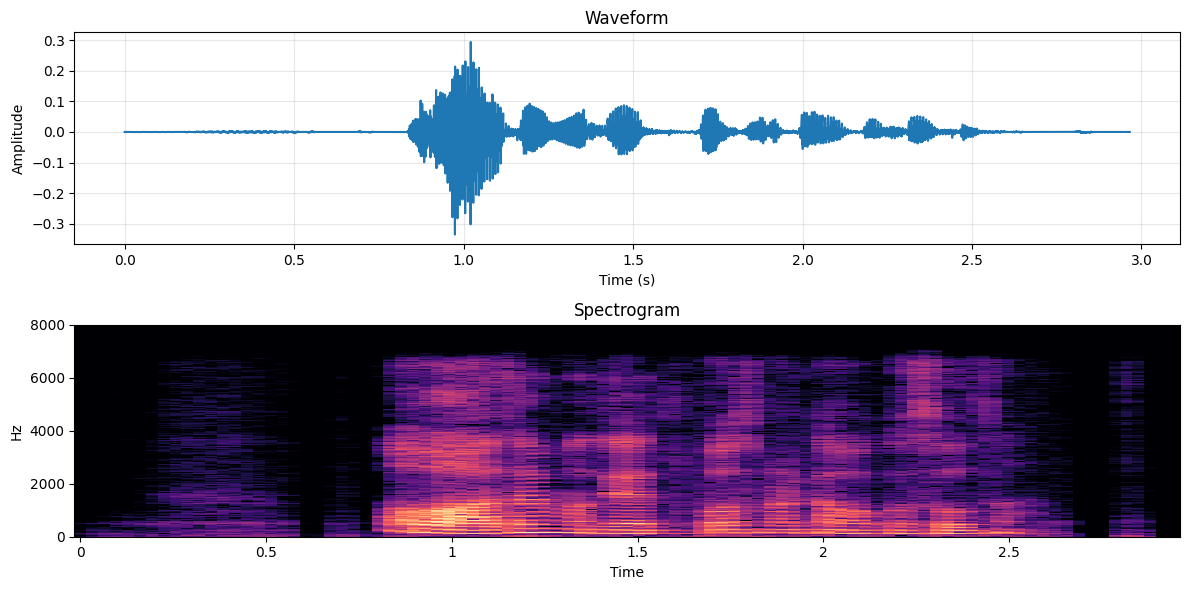


💡 RECOMMENDATIONS:


In [5]:
# Analyze audio quality
print("🔍 AUDIO QUALITY ANALYSIS\n")
print("="*60)

# Check amplitude
max_amp = np.max(np.abs(audio))
rms = np.sqrt(np.mean(audio**2))
print(f"Peak amplitude: {max_amp:.4f} {'⚠️ TOO QUIET' if max_amp < 0.1 else '✅'}")
print(f"RMS level: {rms:.4f} {'⚠️ TOO QUIET' if rms < 0.01 else '✅'}")

# Check for clipping
clipping = np.sum(np.abs(audio) > 0.99)
print(f"Clipping samples: {clipping} {'⚠️ CLIPPING' if clipping > 0 else '✅'}")

# Check SNR estimate
# Simple noise floor estimation
sorted_audio = np.sort(np.abs(audio))
noise_floor = np.mean(sorted_audio[:len(sorted_audio)//10])  # Bottom 10%
signal_level = np.mean(sorted_audio[-len(sorted_audio)//10:])  # Top 10%
snr_estimate = 20 * np.log10(signal_level / (noise_floor + 1e-10))
print(f"Estimated SNR: {snr_estimate:.1f} dB {'⚠️ NOISY' if snr_estimate < 15 else '✅'}")

# Plot waveform and spectrogram
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Waveform
axes[0].plot(np.linspace(0, duration, len(audio)), audio)
axes[0].set_title('Waveform')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

# Spectrogram
D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', ax=axes[1])
axes[1].set_title('Spectrogram')

plt.tight_layout()
plt.show()

print("\n💡 RECOMMENDATIONS:")
if max_amp < 0.1:
    print("  - Audio is very quiet - normalization recommended")
if snr_estimate < 15:
    print("  - High noise level detected - noise reduction recommended")
if clipping > 0:
    print("  - Audio is clipping - may cause distortion")

## 🔧 Step 2: Advanced Audio Preprocessing

In [6]:
def enhance_audio(audio, sr):
    """Apply advanced audio enhancement"""
    enhanced = audio.copy()
    
    # 1. Noise reduction
    print("  🔧 Applying noise reduction...")
    enhanced = nr.reduce_noise(y=enhanced, sr=sr, prop_decrease=0.8)
    
    # 2. Bandpass filter (80 Hz - 8000 Hz for speech)
    print("  🔧 Applying bandpass filter...")
    nyquist = sr / 2
    low = 80 / nyquist
    high = 8000 / nyquist
    b, a = butter(4, [low, high], btype='band')
    enhanced = filtfilt(b, a, enhanced)
    
    # 3. Normalize
    print("  🔧 Normalizing amplitude...")
    peak = np.max(np.abs(enhanced))
    if peak > 0:
        enhanced = enhanced * (0.9 / peak)
    
    # 4. Trim silence
    print("  🔧 Trimming silence...")
    enhanced, _ = librosa.effects.trim(enhanced, top_db=20)
    
    return enhanced

print("🔧 Enhancing audio...\n")
enhanced_audio = enhance_audio(audio, sr)

print("\n✅ Enhancement complete!")
print(f"Original length: {len(audio)/sr:.2f}s")
print(f"Enhanced length: {len(enhanced_audio)/sr:.2f}s")

# Save enhanced audio
sf.write('enhanced_audio.wav', enhanced_audio, sr)

print("\n🎧 Compare original vs enhanced:")
print("Original:")
display(Audio(audio, rate=sr))
print("Enhanced:")
display(Audio(enhanced_audio, rate=sr))

🔧 Enhancing audio...

  🔧 Applying noise reduction...
  🔧 Applying bandpass filter...


ValueError: Digital filter critical frequencies must be 0 < Wn < 1

## 🎯 Step 3: Test with Enhanced Audio

In [ ]:
from faster_whisper import WhisperModel

# Enhanced prompt with phonetic hints
enhanced_prompt = (
    "Transcrição de uma chamada telefónica para a Clínica Dentária Sol Nascente em Portugal. "
    "A pessoa fala português europeu (pt-PT). "
    "Vocabulário importante: dente, dentes, dor de dentes, dentista, dentária, "
    "consulta, marcação, marcar, remarcar, cancelar, urgência, emergência, "
    "limpeza, obturação, ortodontia, aparelho, branqueamento, coroa, implante, "
    "extração, cárie, gengivite, periodontite, prótese, "
    "seguro de saúde, ADSE, Multicare, Médis, AdvanceCare, "
    "receção, recepcionista, horário, disponibilidade, check-up."
)

print("🎯 Testing Faster-Whisper with enhanced audio...\n")

model = WhisperModel("large-v3", device="cuda" if device == "cuda" else "cpu", 
                     compute_type="float16" if device == "cuda" else "int8")

# Test with original audio
print("📊 Original audio:")
segments, info = model.transcribe(
    audio,
    language="pt",
    initial_prompt=enhanced_prompt,
    beam_size=5,
    best_of=5,
    temperature=0.0,
    vad_filter=True,
    vad_parameters=dict(min_silence_duration_ms=500),
    word_timestamps=True  # Get word-level timestamps
)

original_transcription = " ".join([segment.text for segment in segments])
print(f"Result: {original_transcription}")
print()

# Test with enhanced audio
print("📊 Enhanced audio:")
segments, info = model.transcribe(
    enhanced_audio,
    language="pt",
    initial_prompt=enhanced_prompt,
    beam_size=5,
    best_of=5,
    temperature=0.0,
    vad_filter=True,
    vad_parameters=dict(min_silence_duration_ms=500),
    word_timestamps=True
)

enhanced_transcription = " ".join([segment.text for segment in segments])
print(f"Result: {enhanced_transcription}")
print()

# Store for later correction
base_transcription = enhanced_transcription

## 🤖 Step 4: LLM-Powered Correction

This is the game-changer: Use an LLM to fix transcription errors based on context

In [ ]:
# Choose your LLM provider
print("🤖 LLM POST-PROCESSING\n")
print("Choose your LLM provider:")
print("1. OpenAI (GPT-4o)")
print("2. Anthropic (Claude)")
print("3. Groq (Llama/Mixtral - free)")
print()

provider = input("Enter choice (1/2/3): ").strip()

if provider == "1":
    api_key = input("Enter OpenAI API key: ").strip()
    from openai import OpenAI
    client = OpenAI(api_key=api_key)
    model_name = "gpt-4o"
    
elif provider == "2":
    api_key = input("Enter Anthropic API key: ").strip()
    from anthropic import Anthropic
    client = Anthropic(api_key=api_key)
    model_name = "claude-3-5-sonnet-20241022"
    
elif provider == "3":
    api_key = input("Enter Groq API key: ").strip()
    from groq import Groq
    client = Groq(api_key=api_key)
    model_name = "llama-3.3-70b-versatile"

print(f"\n✅ Using {model_name}")

In [ ]:
def correct_transcription_with_llm(transcription, provider_choice, client, model):
    """Use LLM to correct transcription errors"""
    
    correction_prompt = f"""Você é um especialista em português europeu (pt-PT) e está a corrigir uma transcrição automática de uma chamada telefónica para uma clínica dentária.

CONTEXTO:
- Clínica: Clínica Dentária Sol Nascente
- Localização: Lisboa, Portugal
- Idioma: Português Europeu (pt-PT), NÃO brasileiro
- Tópico: Chamada sobre consultas dentárias, marcações, urgências, etc.

VOCABULÁRIO COMUM:
- Anatomia: dente, dentes, gengiva, maxilar, mandíbula
- Serviços: consulta, limpeza, obturação, extração, branqueamento, ortodontia, implante, coroa, prótese, check-up
- Problemas: dor de dentes, cárie, gengivite, periodontite, sensibilidade, inflamação
- Ações: marcar, remarcar, cancelar, urgência, emergência
- Seguros: ADSE, Multicare, Médis, AdvanceCare
- Horários: segunda-feira, terça-feira, quarta-feira, quinta-feira, sexta-feira, sábado, domingo

ERROS COMUNS A CORRIGIR:
- "dente" mal transcrito como "de", "tente", "ente", "deente"
- "consulta" como "consultar", "consuta"
- "marcação" como "marcação", "marcacão"
- Pronomes pt-PT: "vossa" não "sua", "tenho" não "eu tenho"
- Acentos: á, ã, ç, é, ê, í, ó, ô, ú

TRANSCRIÇÃO ORIGINAL:
{transcription}

INSTRUÇÕES:
1. Corrija APENAS erros óbvios de transcrição
2. Mantenha o português europeu (pt-PT)
3. Adicione pontuação adequada
4. Corrija acentos e cedilhas
5. Capitalize nomes próprios (Clínica Dentária Sol Nascente, ADSE, etc.)
6. NÃO invente informação que não está na transcrição
7. NÃO mude o significado, apenas corrija erros de transcrição

Retorne APENAS a transcrição corrigida, sem explicações adicionais."""
    
    print("🤖 Sending to LLM for correction...\n")
    
    if provider_choice == "1":  # OpenAI
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "Você é um especialista em português europeu e transcrição."},
                {"role": "user", "content": correction_prompt}
            ],
            temperature=0.1
        )
        return response.choices[0].message.content
    
    elif provider_choice == "2":  # Anthropic
        response = client.messages.create(
            model=model,
            max_tokens=2000,
            temperature=0.1,
            messages=[
                {"role": "user", "content": correction_prompt}
            ]
        )
        return response.content[0].text
    
    elif provider_choice == "3":  # Groq
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "Você é um especialista em português europeu e transcrição."},
                {"role": "user", "content": correction_prompt}
            ],
            temperature=0.1
        )
        return response.choices[0].message.content

# Apply correction
corrected_transcription = correct_transcription_with_llm(base_transcription, provider, client, model_name)

print("="*80)
print("📊 RESULTS COMPARISON")
print("="*80)
print()
print("ORIGINAL STT OUTPUT:")
print(base_transcription)
print()
print("-"*80)
print()
print("LLM-CORRECTED OUTPUT:")
print(corrected_transcription)
print()
print("="*80)

## 📝 Step 5: Manual Evaluation

Now compare with the actual content

In [ ]:
print("📝 Please provide the actual/expected transcription for comparison:\n")
ground_truth = input("Paste the correct transcription (or type 'skip'): ").strip()

if ground_truth.lower() != 'skip':
    print("\n" + "="*80)
    print("THREE-WAY COMPARISON")
    print("="*80)
    print()
    print("1️⃣ GROUND TRUTH (Actual):")
    print(ground_truth)
    print()
    print("-"*80)
    print()
    print("2️⃣ RAW STT OUTPUT:")
    print(base_transcription)
    print()
    print("-"*80)
    print()
    print("3️⃣ LLM-CORRECTED:")
    print(corrected_transcription)
    print()
    print("="*80)
    
    # Simple word-level comparison
    def word_error_rate(reference, hypothesis):
        ref_words = reference.lower().split()
        hyp_words = hypothesis.lower().split()
        
        # Simple approximation
        matches = sum(1 for w in hyp_words if w in ref_words)
        accuracy = matches / max(len(ref_words), len(hyp_words)) * 100
        return accuracy
    
    stt_accuracy = word_error_rate(ground_truth, base_transcription)
    corrected_accuracy = word_error_rate(ground_truth, corrected_transcription)
    
    print(f"\n📊 Approximate Word Accuracy:")
    print(f"   Raw STT: {stt_accuracy:.1f}%")
    print(f"   LLM-Corrected: {corrected_accuracy:.1f}%")
    print(f"   Improvement: {corrected_accuracy - stt_accuracy:+.1f}%")
    
    # Check if "dente" appears
    print(f"\n🔍 'dente' check:")
    print(f"   Ground truth contains 'dente': {'✅' if 'dente' in ground_truth.lower() else '❌'}")
    print(f"   Raw STT contains 'dente': {'✅' if 'dente' in base_transcription.lower() else '❌'}")
    print(f"   Corrected contains 'dente': {'✅' if 'dente' in corrected_transcription.lower() else '❌'}")

## 💾 Save Results

In [ ]:
import json

results = {
    "audio_file": audio_path,
    "audio_duration_seconds": duration,
    "raw_stt_output": base_transcription,
    "llm_corrected_output": corrected_transcription,
    "llm_provider": model_name,
    "audio_enhanced": True
}

with open('correction_results.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("✅ Results saved to correction_results.json")
files.download('correction_results.json')

## 🚀 Production Integration Code

If the LLM correction works well, here's how to integrate it into your FastAPI app:

In [ ]:
production_code = '''
# Add to your main.py

def correct_transcription(text: str, client) -> str:
    """Post-process transcription with LLM correction"""
    
    correction_prompt = f"""Corrija esta transcrição de português europeu de uma clínica dentária.
    
Vocabulário: dente, consulta, marcação, dentista, ADSE, Multicare, Médis.
Corrija apenas erros óbvios. Mantenha pt-PT.

Transcrição: {text}

Retorne apenas a transcrição corrigida:"""
    
    # Using Groq (already in your stack)
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",  # Fast and free
        messages=[
            {"role": "user", "content": correction_prompt}
        ],
        temperature=0.1,
        max_tokens=500
    )
    
    return response.choices[0].message.content.strip()


@app.post("/transcribe")
async def transcribe(audio: UploadFile = File(...)):
    # ... your existing code ...
    
    # After getting Whisper transcription
    raw_transcription = result.strip()
    
    # Apply LLM correction
    corrected = correct_transcription(raw_transcription, client)
    
    return {"text": corrected, "raw": raw_transcription}
'''

print(production_code)